Statistics and data visualization go hand in hand. In this workshop, we'll walk through some basic statistical concepts, learn how to implement them in python, and then visualize them. First, let's import some libraries that we'll be using. 

We'll be using stock market data in today's workshop. To get the data, we'll use a library called yfinance. Yfinance is a package that scrapes data from Yahoo Finance for any publicly traded company or currency. It's a quick, free, and extremely convenient way to access real-time and historical market data.

In [1]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
import random
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf

Exploratory Data Viz, Descriptive Stats


Let's get some data. We'll be at the price of Microsoft stock over the previous two years. Microsoft trades under the ticker 'MSFT', but feel free to change this to any ticker you'd like after going through the workshop. The .download() method in yfinance returns a pandas dataframe containing the data we requested.

In [2]:
ticker=['MSFT']
data = yf.download(ticker, period='2y')
data.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2024-02-26,401.379425,405.929582,401.202123,405.240151,16193500
2024-02-27,401.320251,402.147550,397.745120,401.822522,14835800
2024-02-28,401.556641,403.112743,399.192927,402.009679,13183100
2024-02-29,407.387177,407.938709,399.783876,402.462760,31947300
2024-03-01,409.218994,409.583396,404.668838,405.052927,17823400


The dataframe returned by the .download() method has a multi-index, which makes it look like there are two names for each column. Each row represents a single day of trading. We can see the closing price (the last price the stock was sold for on the day), the highest and lowest price the stock reached during the day, the opening price, and the volume (the number of shares that were traded during the day). It also uses the date as the index, which can be tricky. We'll create a new dataframe to clean this up. We'll give the date it's own column and only keep the closing price column to keep it simple. We'll also create a new column to show the daily return (ie, the percentage change from the previous day).

In [3]:
df=pd.DataFrame(columns=['date','MSFT_close', 'MSFT_return'])
#list to store the previous day price - this will help with calculating the daily returns
msft_prev=[]
#we'll store the daily returns in this list. We'll say the first day in the dataset will have a return of 0%.
msft_return=[0]

for index, row in data.iterrows():
    if len(msft_prev)>0:
        #subtract current day price from previous day price and divide by previous day price to get proportion of change
        msft_chg=(row['Close']['MSFT']-msft_prev[-1])/msft_prev[-1]
        #convert proportion to percentage and append the daily return to the msft_return list
        msft_return.append(msft_chg*100)
        #append current day price to previous day price list for use "tomorrow"
        msft_prev.append(row['Close']['MSFT'])
    else:
        msft_prev.append(row['Close']['MSFT'])
    #add a new row to our empty dataframe - we'll need the date (which is the index), the closing price, and the daily return.
    df.loc[len(df)]=[index, row['Close']['MSFT'], msft_return[-1]]
df.head()

,date,MSFT_close,MSFT_return
0,2024-02-26,401.379425,0.000000
1,2024-02-27,401.320251,-0.014743
2,2024-02-28,401.556641,0.058903
3,2024-02-29,407.387177,1.451983
4,2024-03-01,409.218994,0.449650


Let's throw this into a function that we can re-use throughout the workshop, and possibly in future projects. The function will take a list of tickers and a time period and return a clean dataframe where each row has the closing price and daily returns for each of our tickers, as well as the date.

In [4]:
def get_tickers(tickers, period):
    #make call to yfinance
    data = yf.download(tickers, period=period)
    #create new dataframe with return data
    cols=['date']
    for t in tickers:
        cols.append(t+'_close')
        cols.append(t+'_return')
    df=pd.DataFrame(columns=cols)
    #create price dictionary. ticker will be key, values will be another dictionary with prices and returns
    d_price={t:{'price':[], 'return':[0]} for t in tickers}
    for index, row in data.iterrows():
        irow=[index]
        for t in tickers:
            if len(d_price[t]['price'])>0:
                #subtract current day price from previous day price and divide by previous day price to get proportion of change
                chg=(row['Close'][t]-d_price[t]['price'][-1])/d_price[t]['price'][-1]
                #convert proportion to percentage and append the daily return to the msft_return list
                d_price[t]['return'].append(chg*100)
                #append current day price to previous day price list for use "tomorrow"
                d_price[t]['price'].append(row['Close'][t])
            else:
                d_price[t]['price'].append(row['Close'][t])
            irow.append(row['Close'][t])
            irow.append(d_price[t]['return'][-1])
        #add a new row to our empty dataframe - we'll need the date (which is the index), the closing price, and the daily return.
        df.loc[len(df)]=irow
    return df

In [33]:
#let's try it out - we'll just use the microsoft ticker for now. Later we'llpull in multiple tickers.
my_tickers=['MSFT']

df=get_tickers(tickers=my_tickers, period='2y')
df.head()

[*********************100%***********************]  1 of 1 completed


,date,MSFT_close,MSFT_return
0,2024-02-26,401.379364,0.000000
1,2024-02-27,401.320282,-0.014720
2,2024-02-28,401.556610,0.058888
3,2024-02-29,407.387177,1.451991
4,2024-03-01,409.219025,0.449658


Perfect! When we first start a data project, we want to spend some time exploring the data. We'll get some high-level descriptive stats (mean, median, standard deviation, etc.) and make some quick and easy visualizations to see what's going on with the data. Let's start by viewing the distribution of the data.

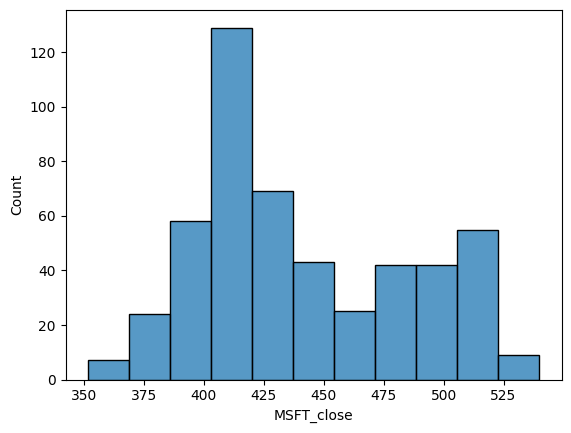

In [34]:
sns.histplot(data=df, x='MSFT_close');

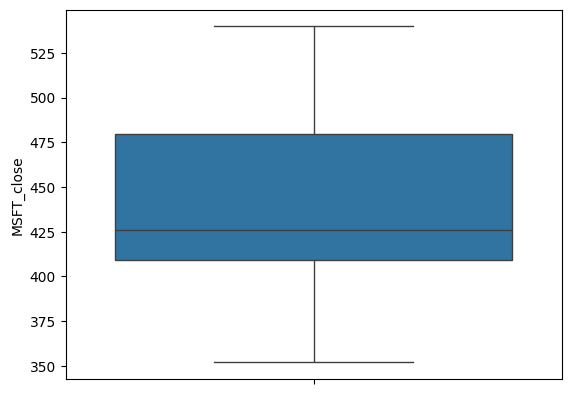

In [35]:
sns.boxplot(y=df.MSFT_close);

In [36]:
mean_price=df.MSFT_close.mean()
median_price=df.MSFT_close.median()

print(f'Mean Price: ${mean_price:,.2f}') 
print(f'Median Price: ${median_price:,.2f}') 

Mean Price: $441.34
Median Price: $425.83


Let's look at the daily returns as well

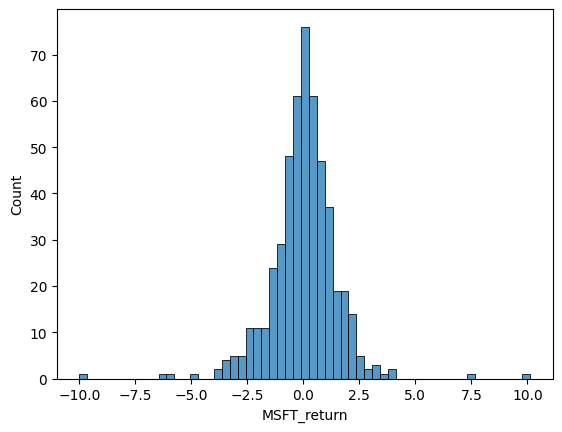

In [39]:
sns.histplot(data=df, x='MSFT_return');

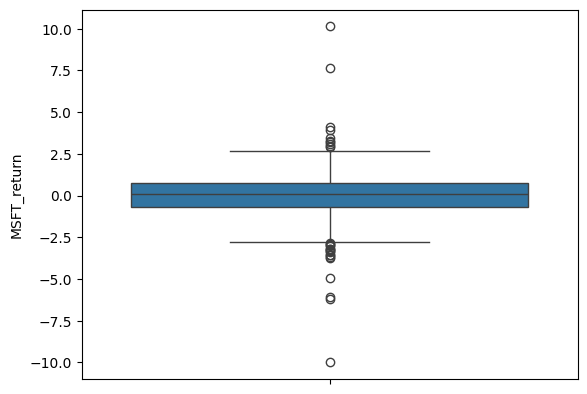

In [40]:
sns.boxplot(y=df.MSFT_return);

Let's also find the mean and standard deviation in the returns

In [9]:
mean_return=df.MSFT_return.mean()
sd_return=df.MSFT_return.std()

print(f'Mean Daily Return: {mean_return:,.2f}%') 
print(f'Standard Deviation: {sd_return:,.2f}%') 

Mean Daily Return: 0.01%
Standard Deviation: 1.51%


The two visuals above can be really useful when we are exploring data in the early stages of a project. However, to make higher quality visualizations in seaborn or matplotlib, start by defining a figure and an axis using the .subplots() method. The "figure" is the overall image, and the "axes" are the plots within the figure. Using this method allows us to create multiple plots in a single figure if we want, and change the size of the figure. We'll use this method whenever we are making something we might want to share with an audience, because it gives us a lot more flexibility. 

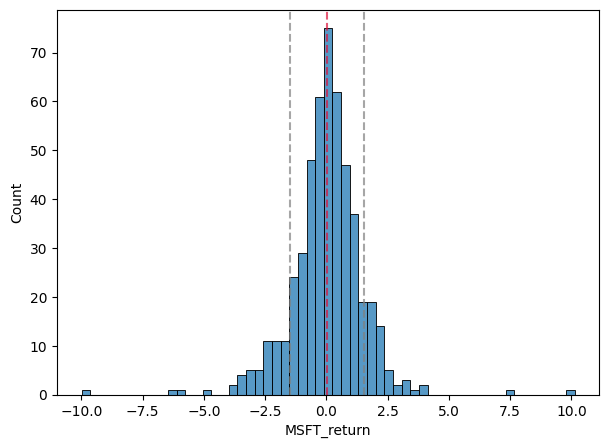

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(data=df, x='MSFT_return', ax=ax)
#let's plot lines at the mean return and the mean +/- a standard deviation to get a sense of how volitile the stock has been
plt.axvline(x=mean_return, color='crimson', linestyle='--', alpha=0.7)
plt.axvline(x=mean_return-sd_return, color='grey', linestyle='--', alpha=0.7)
plt.axvline(x=mean_return+sd_return, color='grey', linestyle='--', alpha=0.7);

Let's make a line plot to see how the price has changed over time. It will also give us more context around these extreme outliers we see in the return distribution.

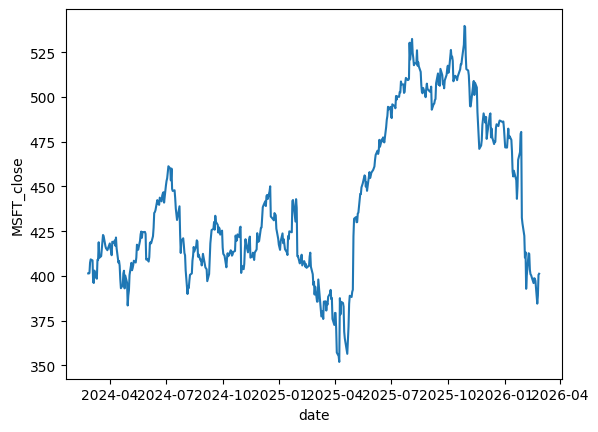

In [41]:
sns.lineplot(data=df, x='date', y='MSFT_close');

There are some interesting price movements happening here. Let's clean this up a bit. We'll also throw in some moving averages using the .rolling() method in pandas. This will hlep us spot any potential underlying trends that might not be evident in the daily price data.

In [12]:
df['30_ma']=df.MSFT_close.rolling(30).mean()
df['50_ma']=df.MSFT_close.rolling(50).mean()
df

,date,MSFT_close,MSFT_return,30_ma,50_ma
0,2024-02-26,401.379395,0.000000,NaN,NaN
1,2024-02-27,401.320221,-0.014743,NaN,NaN
2,2024-02-28,401.556610,0.058903,NaN,NaN
3,2024-02-29,407.387146,1.451984,NaN,NaN
4,2024-03-01,409.218994,0.449658,NaN,NaN
...,...,...,...,...,...
498,2026-02-20,397.230011,-0.308684,434.511119,453.133068
499,2026-02-23,384.470001,-3.212247,431.426078,451.004478
500,2026-02-24,389.000000,1.178245,428.453126,449.235074
501,2026-02-25,400.600006,2.982007,425.936682,447.599694


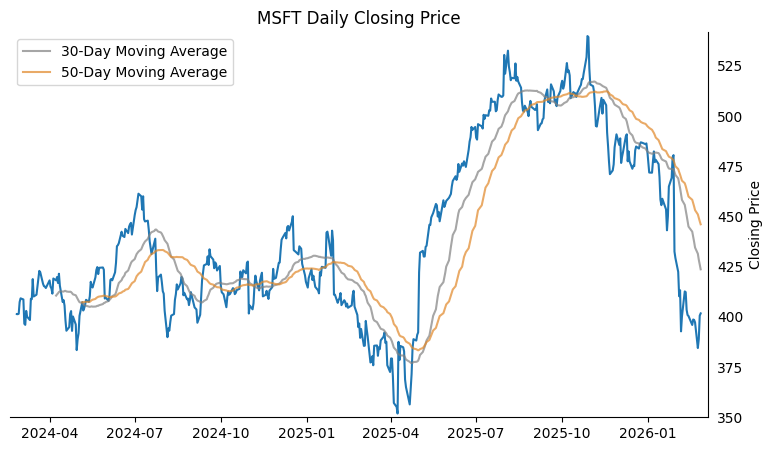

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))

#main price plot
sns.lineplot(data=df, x='date', y='MSFT_close', ax=ax)

#add 30-day moving average. This will be it's own line plot that we'll plot on the same axis
sns.lineplot(data=df, x='date', y='30_ma', label='30-Day Moving Average', color='grey', alpha=0.7, ax=ax)

#add 50-day moving average
sns.lineplot(data=df, x='date', y='50_ma', label='50-Day Moving Average', color='#e18727ff', alpha=0.7, ax=ax)

#update axis labels and title - remove x-label, clean up y-label and add title
ax.set(xlabel='', ylabel='Closing Price', title='MSFT Daily Closing Price')

#move the y-axis to the right side, since the most recent data is what we care about
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')

#close margins to remove space between axes and the data
ax.margins(x=0.01, y=0.01)

#remove spine from left and top of chart to give more open look
sns.despine(top=True, left=True, right=False);

Central Limit Theorem

Now that we've explored the data and found some descriptive statistics, we want to go further and make some inferences. To do this, we rely on the Central Limit Theorem. The CLT tells us that when independent samples are drawn from a population, the distribution of the sample statistics will be normally distributed given a large enough sample size. Amazingly, this works regardless of the nature of population distribution. 

Let's prove how this works using the power of programming. Let's get a "population" of numbers that we know will have a very abnormal distribution, such as a stock price over a long period of time. Let's take the S&P 500 Index (SPY) over the previous 5 years.

In [14]:
df=get_tickers(tickers=['SPY'], period='5y')
df.head()

[*********************100%***********************]  1 of 1 completed


,date,SPY_close,SPY_return
0,2021-02-26,355.057007,0.000000
1,2021-03-01,363.663666,2.424022
2,2021-03-02,360.825897,-0.780328
3,2021-03-03,356.046539,-1.324561
4,2021-03-04,351.640564,-1.237472


Let's check out the price distribution in a histogram and print the mean price.

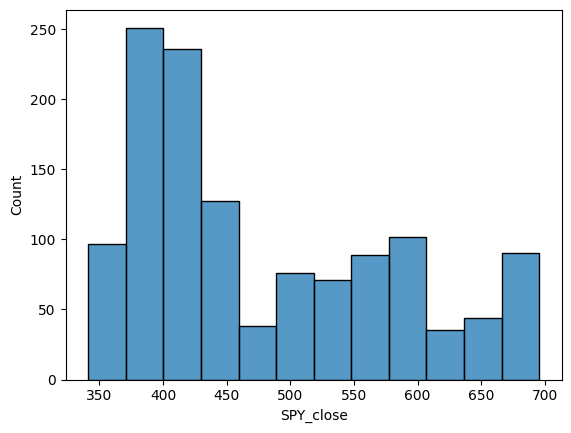

In [15]:
sns.histplot(data=df,x='SPY_close');

In [16]:
mean_price=np.mean(df.SPY_close)
print(f'Mean Price: ${mean_price:,.2f}') 

Mean Price: $479.84


Definitely not a normal distribution. However, the CLT tells us that the mean price that we calcualte from random samples should approach a normal distribution if our sample size is large enough. Let's give it a shot with a few different sample sizes. We'll use a numpy method called .random.sample() to draw the samples.

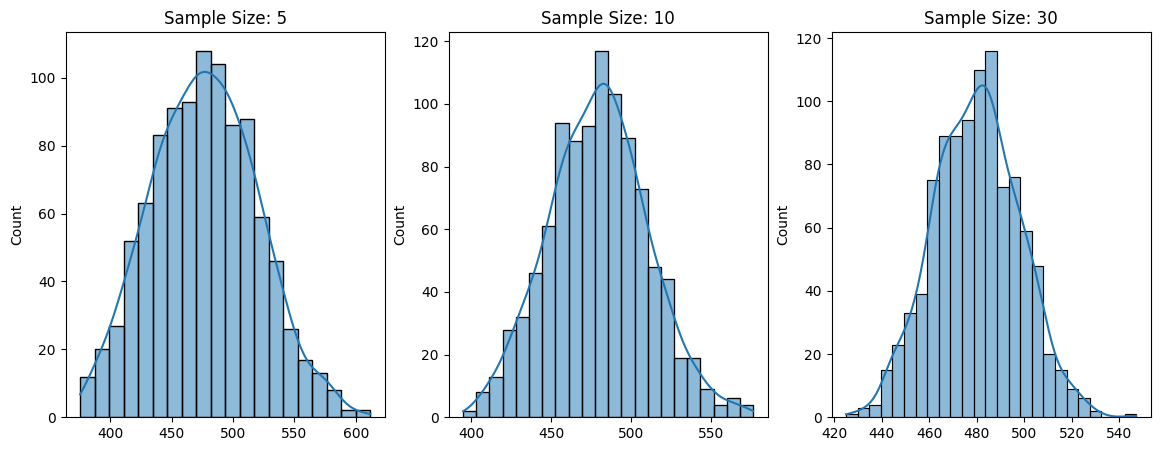

In [17]:
#we'll take samples of 10, 25, and 50 days, and do 1,000 of each. We'll store the sample means in a dictionary, using the sample size as the key
d_samples={5:[], 10:[], 30:[]}

for s in d_samples:
    for i in range(1000):
        sample = np.random.choice(df.SPY_close, size=s, replace=False)
        sample_mean=np.mean(sample)
        d_samples[s].append(sample_mean)

#now we'll plot each of the sampling distributions in a histogram
fig, ax = plt.subplots(1,3, figsize=(14, 5))

for a, s in zip(ax,d_samples):
    sns.histplot(x=d_samples[s], kde=True, ax=a)
    a.set(title='Sample Size: '+str(s));

Amazing. The 10-day samples look nearly normal, and the 30 day samples look about perfect. Let's draw some confidence intervals from our random samples of 30 and see if they truly capture the population mean as often as they claim. We'll plot the results in a multi-plot figure to demonstrate what we did. 

We'll use a function to calculate the confidence intervals.

In [18]:
def conf_int_t(data, conf_level):
    n=len(data)
    df=n-1
    sample_std=np.std(data, ddof=1)
    sample_mean=np.mean(data)
    #step 1 - find std error of sample dist
    sem=sample_std/np.sqrt(n)
    #step 2 - find critical t-value
    alpha=1-conf_level
    q=1-(alpha/2)
    t=stats.t.ppf(q, df)
    #step 3 - find margin of error
    me=sem*t
    #step 4 - contruct interval
    ci=(sample_mean-me, sample_mean+me)
    return ci

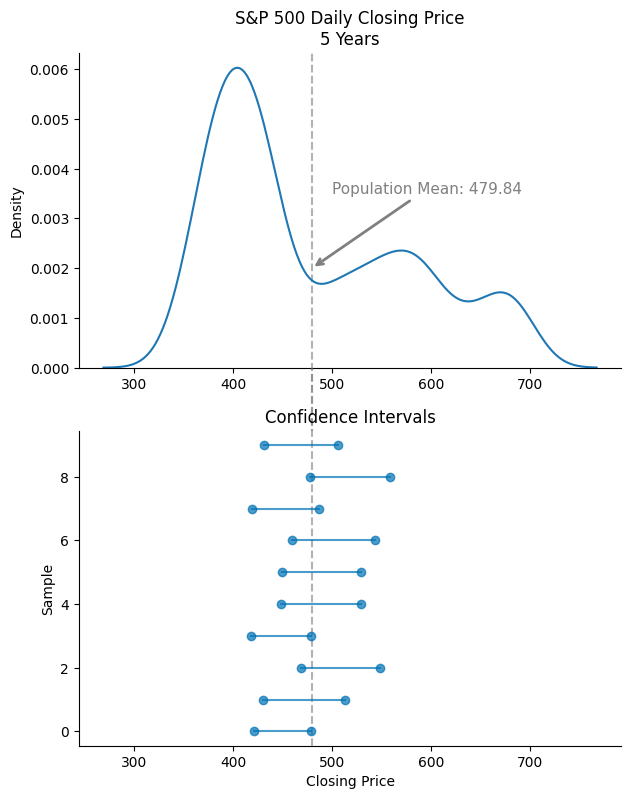

In [19]:
fig, ax = plt.subplots(2,1, figsize=(7, 9), sharex=True)
sns.despine(right=True, top=True)

#popultaion plot will be on top - showing the distribution of all prices
sns.kdeplot(x=df.SPY_close, ax=ax[0]).set_title('S&P 500 Daily Closing Price\n5 Years');
ax[0].xaxis.set_tick_params(which='both', labelbottom=True)

#draw line across entire figure at the population mean
pop_mean=np.mean(df.SPY_close)
ax[0].axvline(x=pop_mean, ymin=-1.2,ymax=1, zorder=0, clip_on=False, linestyle='--', color='grey', alpha=0.6)
ax[1].axvline(x=pop_mean, ymin=0,ymax=1.2, zorder=0, clip_on=False, linestyle='--', color='grey', alpha=0.6)

#confidence intervals - let's take 10 samples of 30 days each and use our confidence interval function to get the lower and upper limits
for i in range(0,10):
    sample = np.random.choice(df.SPY_close, size=s, replace=False)
    ci=conf_int_t(data=sample, conf_level=0.95) #plug in any confidence level you want here
    ax[1].plot([ci[0], ci[1]], [i, i], '-o', color='#0072b5ff', alpha=0.7)
ax[1].set(ylabel='Sample', xlabel='Closing Price', title='Confidence Intervals')
ax[0].annotate('Population Mean: '+str(round(pop_mean,2)), #add what we want 
            xy=(pop_mean, 0.002), xytext=(500, 0.0035), # xy: The end point of the arrow (arrowhead position); xytext: The start point of the arrow (arrow tail position)
            arrowprops=dict(arrowstyle='->', color='grey', lw=2), #lw: linewidth in pixels
            fontsize=11, color='grey');

Did every sample capture the true population mean? Remember, with a 95% confidence interval, it should capture the true mean 95% of the time. Try changing the confidence level to improve your understanding of the concept.

Correlation and Regression

While we are exploring the data, we can also start looking at potential correlations with other securities. To effectively diversify a portfolio, we want to find securities with very low correlations. If two securities are highly correlated, we might be better off just picking one of them. Let's look at Oracle, another one of the AI "hyperscalers". We'll use our handy function to fetch the data and clean it up.

In [20]:
tickers=['MSFT', 'ORCL']

df=get_tickers(tickers=tickers, period='2y')
df.head()

[*********************100%***********************]  2 of 2 completed


,date,MSFT_close,MSFT_return,ORCL_close,ORCL_return
0,2024-02-26,401.379333,0.000000,108.682991,0.000000
1,2024-02-27,401.320251,-0.014720,109.084541,0.369469
2,2024-02-28,401.556641,0.058903,109.378365,0.269354
3,2024-02-29,407.387146,1.451976,109.378365,0.000000
4,2024-03-01,409.218994,0.449658,111.435081,1.880369


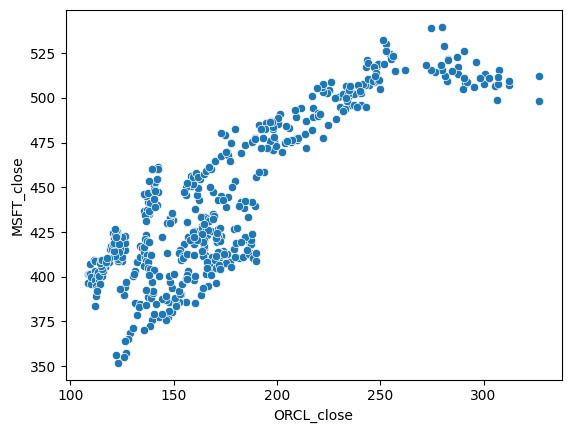

In [21]:
sns.scatterplot(data=df,x='ORCL_close', y='MSFT_close');

Visually, it seems like there is a pretty strong positive correlation between oracle and microsoft. Let's fit a linear model to the data and calculate the correlation coefficient. We'll use the stats module of the scipy library, which is an extremely useful package for all things data analysis.

We'll use the .linregress() method, which will take our two data series (msft prices and orcl prices) and give us the slope, intercept, correlation coefficient (r), p-value, and a standard error.

In [22]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df.MSFT_close, df.ORCL_close)

#let's print the linear formula and r value
print(f'Correlation (r): {round(r_value,2)}')
print(f'y={round(intercept,2)}+{round(slope,2)}x')

Correlation (r): 0.86
y=-253.62+0.97x


This is a really strong correlation. I think this is good evidence to not own both of these stocks at the moment. Let's plot our linear model and display the correlation and formula. We'll also show error bands in the linear model to represent the fact that the model parameters are random variables in a sampling distribution.

We'll use the .regplot() method in Seaborn. This will essentially create a scatterplot with a line plot on top to show the linear model. The .regplot() method will allow us to style the points and the line separately.

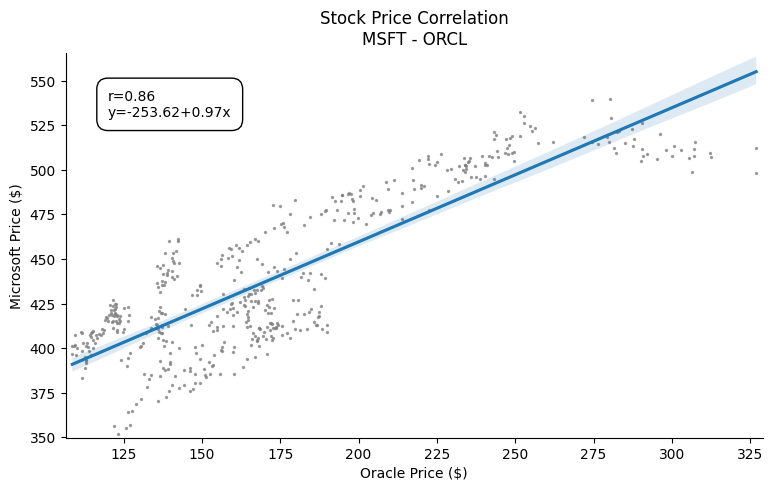

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))

#regplot
sns.regplot(data=df,x='ORCL_close', y='MSFT_close', ci=99, #this is where we set the confidence interval
            scatter_kws={'s':2,'alpha':0.7, 'color':'grey'}, 
            line_kws={},
            ax=ax)

#axis labels and title
linear_model=f'y={round(intercept,2)}+{round(slope,2)}x'
ax.set(xlabel='Oracle Price ($)', ylabel='Microsoft Price ($)', title='Stock Price Correlation\nMSFT - ORCL')

#annotate with correlation coefficient and linear model
linear_model=f'y={round(intercept,2)}+{round(slope,2)}x'
ax.text(120,530, f'r={round(r_value,2)}\n{linear_model}', #x-coordinate, y-coordinate, text
       bbox={'edgecolor':'black', 
             'facecolor':'white', 
             'pad':0.8,
             'boxstyle':'round'})

#close margins to remove space between axes and the data
ax.margins(x=0.01, y=0.01)

#despine plot
sns.despine(top=True, right=True);

We can also look at some estimates around the mean daily return of a few different stocks. Let's look at the mean price of the Magnificent Seven, the top 7 companies in the US stock market (and world). Let's just look at the last three months of trading. We'll use our function again to get the data.

In [24]:
mag7=['MSFT', 'NVDA', 'AAPL', 'GOOG', 'META', 'TSLA', 'AMZN']

df=get_tickers(tickers=mag7, period='3mo')
df.head()

[*********************100%***********************]  7 of 7 completed


,date,MSFT_close,MSFT_return,NVDA_close,NVDA_return,AAPL_close,AAPL_return,GOOG_close,GOOG_return,META_close,META_return,TSLA_close,TSLA_return,AMZN_close,AMZN_return
0,2025-11-26,484.394379,0.000000,180.249954,0.000000,277.290527,0.000000,320.071167,0.000000,633.093628,0.000000,426.579987,0.000000,229.160004,0.000000
1,2025-11-28,490.889587,1.340893,176.990143,-1.808495,278.589325,0.468389,319.911285,-0.049952,647.421997,2.263231,430.170013,0.841584,233.220001,1.771687
2,2025-12-01,485.631561,-1.071122,179.909988,1.649722,282.835358,1.524119,314.914520,-1.561922,640.347717,-1.092684,430.140015,-0.006974,233.880005,0.282996
3,2025-12-02,488.884155,0.669766,181.449905,0.855937,285.922455,1.091482,315.813934,0.285606,646.572632,0.972115,429.239990,-0.209240,234.419998,0.230885
4,2025-12-03,476.642090,-2.504083,179.580002,-1.030534,283.884369,-0.712811,320.410950,1.455609,639.078735,-1.159019,446.739990,4.076973,232.380005,-0.870230


We need to restructure this dataset so that it's ready for a bar plot. Each row should have a date, a single ticker, and the return. Therefore, each date should have 7 rows, one for each ticker. We'll call the new dataframe df_bar since it's structured specifically for our bar plot.

In [25]:
df_bar=pd.DataFrame(columns=['date', 'ticker', 'return'])

for index, row in df.iterrows():
    for t in mag7:
        df_bar.loc[len(df_bar)]=[row.date, t, row[t+'_return']]
df_bar

,date,ticker,return
0,2025-11-26,MSFT,0.000000
1,2025-11-26,NVDA,0.000000
2,2025-11-26,AAPL,0.000000
3,2025-11-26,GOOG,0.000000
4,2025-11-26,META,0.000000
...,...,...,...
429,2026-02-26,AAPL,-0.619922
430,2026-02-26,GOOG,-1.820916
431,2026-02-26,META,0.566785
432,2026-02-26,TSLA,-2.077140


Perfect. Bar plot time.

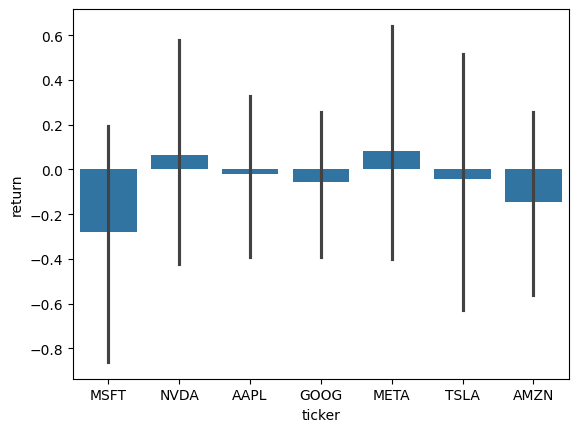

In [26]:
sns.barplot(data=df_bar, x='ticker', y='return');

Let's clean this up we'll make two versions of the plot with different confidence levels. We'll put them in the same figure

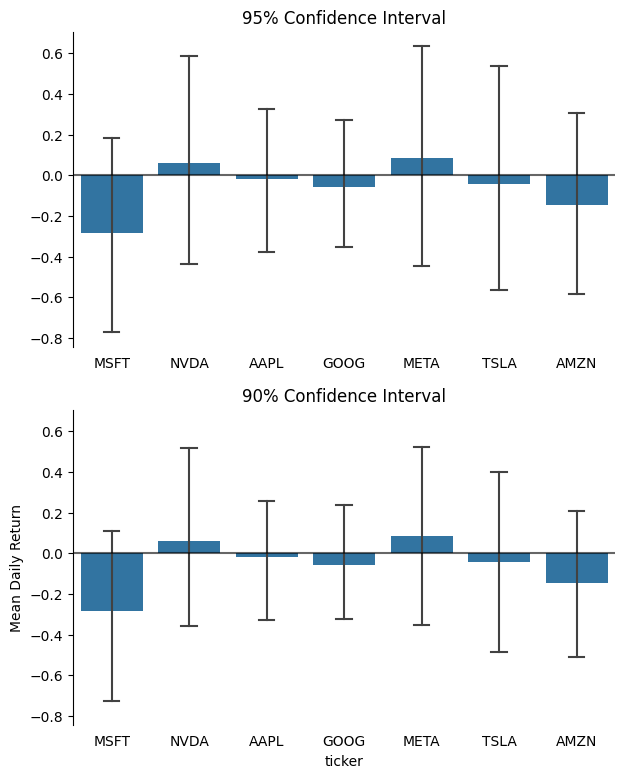

In [27]:
fig, ax = plt.subplots(2,1, figsize=(7, 9), sharex=True, sharey=True)
sns.despine(right=True, top=True, bottom=True)

#95% ci
sns.barplot(data=df_bar, y='return', x='ticker',errorbar=('ci', 95), capsize=0.2, err_kws={'linewidth': 1.5}, ax=ax[0])
ax[0].set(ylabel='',title='95% Confidence Interval')
#draw a line at 0 to identify stocks with average positive vs negative returns
ax[0].axhline(y=0, color='black', linestyle='-', alpha=0.6)
#remove ticks from x axis
ax[0].tick_params(bottom=False, labelbottom=True) 

#90% ci
sns.barplot(data=df_bar, y='return', x='ticker',errorbar=('ci', 90), capsize=0.2, err_kws={'linewidth': 1.5}, ax=ax[1])
ax[1].set(ylabel='Mean Daily Return',title='90% Confidence Interval')
#draw a line at 0 to identify stocks with average positive vs negative point estimates
ax[1].axhline(y=0, color='black', linestyle='-', alpha=0.6)
#remove ticks from x axis
ax[1].tick_params(bottom=False) ;

Let's do a similar version with a point plot (dot plot) and see which one we like better. Let's also switch up the x and y axes to see if that looks better

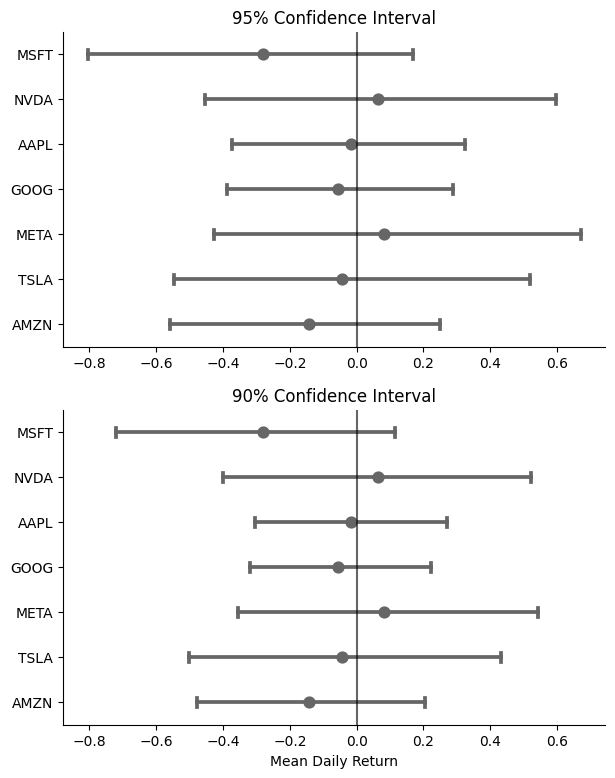

In [28]:
fig, ax = plt.subplots(2,1, figsize=(7, 9), sharex=True, sharey=True)
sns.despine(right=True, top=True)

#95% ci
sns.pointplot(data=df_bar,y='ticker', x='return', linestyle='none', capsize=.2,
             errorbar=("ci", 95), color='0.4', ax=ax[0])
ax[0].set(ylabel='', xlabel='', title='95% Confidence Interval')
ax[0].tick_params(labelbottom=True)
#draw a line at 0 to identify stocks with average positive vs negative point estimates
ax[0].axvline(x=0, color='black', linestyle='-', alpha=0.6)

#90% ci
sns.pointplot(data=df_bar,y='ticker', x='return', linestyle='none', capsize=.2,
             errorbar=("ci", 90), color='0.4', ax=ax[1])
ax[1].set(ylabel='', xlabel='Mean Daily Return', title='90% Confidence Interval')
#draw a line at 0 to identify stocks with average positive vs negative returns
ax[1].axvline(x=0, color='black', linestyle='-', alpha=0.6);